# Dota 2 Match Outcome Prediction
## Logistic Regression Analysis -- Patch 7.41

**Dataset:** 1,500 competitive matches, Dota 2 patch 7.41  
**Objective:** Binary classification -- predict whether Radiant team wins (`radiant_win`)  
**Method:** Logistic Regression with L2 regularization (scikit-learn)  
**Context:** All features are 10-minute match snapshots (early-game outcome prediction)

---
*Prepared for IEEE academic publication*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score, f1_score
)

# Single random seed used throughout -- cite this value in the paper for reproducibility
RANDOM_STATE = 42

# Publication-quality figure settings (IEEE style)
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 13,
    'figure.dpi': 120,
})
SAVE_DPI = 300  # IEEE double-column format requires >=300 DPI

print("Environment ready. RANDOM_STATE =", RANDOM_STATE)

In [7]:
df = pd.read_csv('match_details_output.csv')

print("=== Dataset: Dota 2 Patch 7.41 ===")
print(f"Matches : {len(df):,}")
print(f"Columns : {df.shape[1]}")

print("\n--- Column data types ---")
print(df.dtypes.to_string())

print("\n--- Missing values per column ---")
missing = df.isnull().sum()
if missing.any():
    print(missing[missing > 0].to_string())
else:
    print("None")

print("\n--- Target distribution (radiant_win) ---")
vc = df['radiant_win'].value_counts()
for label, count in vc.items():
    print(f"  {label}: {count:>4}  ({count / len(df) * 100:.1f}%)")

print("\n--- First 5 rows ---")
df.head()

=== Dataset: Dota 2 Patch 7.41 ===
Matches : 1,500
Columns : 16

--- Column data types ---
match_id                        int64
radiant_win                      bool
duration                        int64
radiant_gold                    int64
dire_gold                       int64
radiant_gold_div                int64
radiant_xp                      int64
dire_xp                         int64
radiant_xp_div                  int64
radiant_wards                   int64
dire_wards                      int64
radiant_wards_div               int64
radiant_towers_destroyed        int64
dire_towers_destroyed           int64
radiant_towers_destroyed_div    int64
radiant_first_blood             int64

--- Missing values per column ---
None

--- Target distribution (radiant_win) ---
  True:  797  (53.1%)
  False:  703  (46.9%)

--- First 5 rows ---


,match_id,radiant_win,duration,radiant_gold,dire_gold,radiant_gold_div,radiant_xp,dire_xp,radiant_xp_div,radiant_wards,dire_wards,radiant_wards_div,radiant_towers_destroyed,dire_towers_destroyed,radiant_towers_destroyed_div,radiant_first_blood
0,8796335304,False,1486,13428,15704,-2276,14870,17924,-3054,9,12,-3,0,0,0,1
1,8796335215,False,2541,14472,16214,-1742,15255,18410,-3155,15,15,0,0,0,0,0
2,8796335084,False,2561,14672,16729,-2057,14507,17167,-2660,14,10,4,0,0,0,0
3,8796335080,True,2036,15254,13468,1786,16628,15023,1605,13,12,1,0,0,0,1
4,8796334864,False,2597,13359,15592,-2233,15055,15697,-642,13,13,0,0,1,-1,0


## 3. Exploratory Data Analysis

### 3.1 Class Balance & Feature Correlations

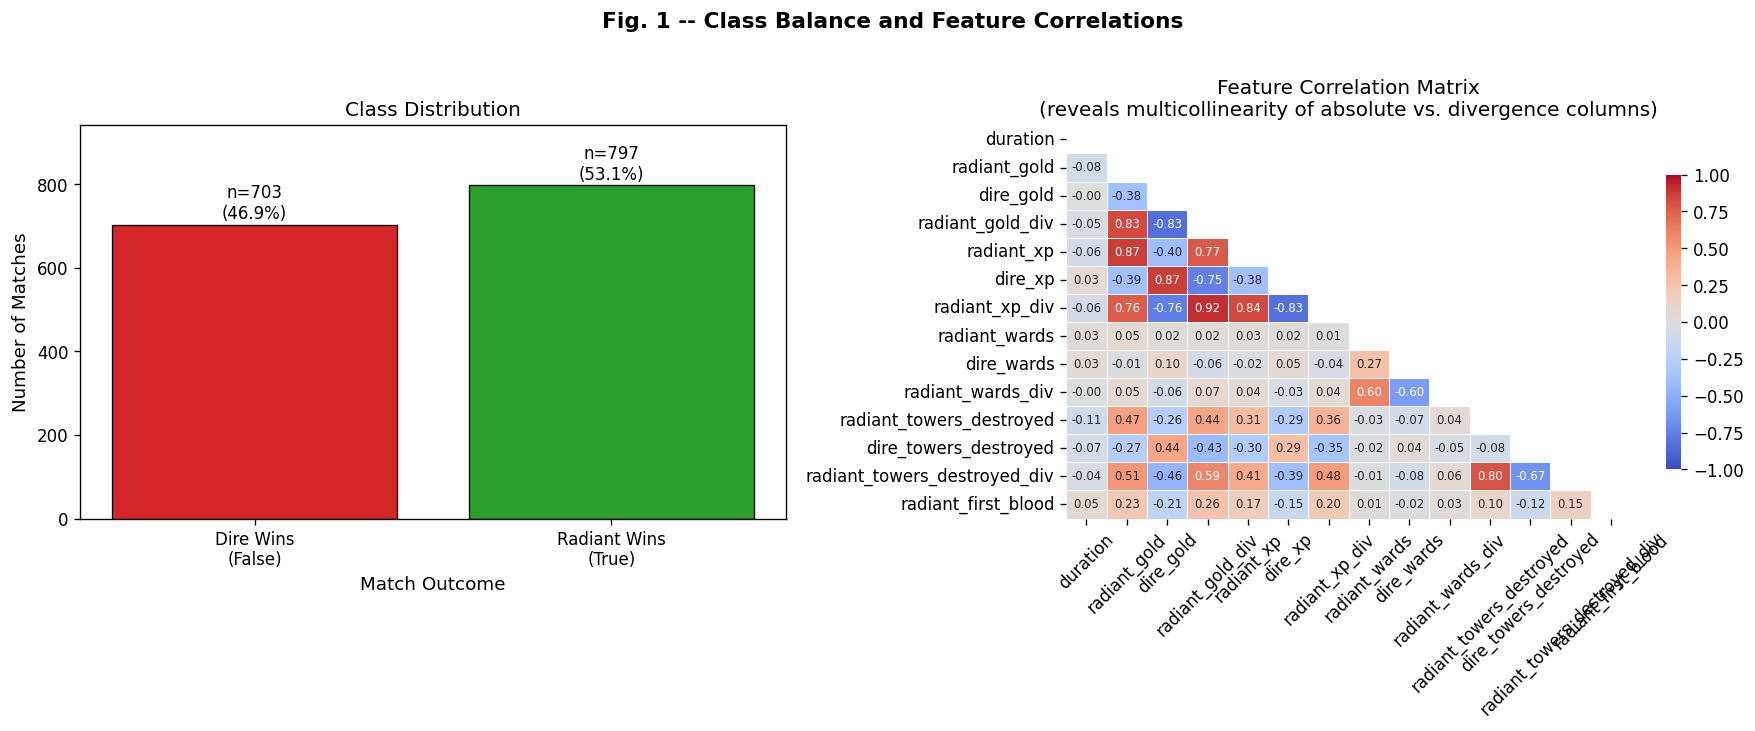

Saved: fig1_class_correlation.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Class distribution ---
win_counts = df['radiant_win'].value_counts()
n_dire    = win_counts.get(False, 0)
n_radiant = win_counts.get(True, 0)

bars = axes[0].bar(
    ['Dire Wins\n(False)', 'Radiant Wins\n(True)'],
    [n_dire, n_radiant],
    color=['#d62728', '#2ca02c'], edgecolor='black', linewidth=0.8
)
for bar, count in zip(bars, [n_dire, n_radiant]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'n={count}\n({count / len(df) * 100:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Matches')
axes[0].set_ylim(0, max(n_dire, n_radiant) * 1.18)
axes[0].set_xlabel('Match Outcome')

# --- Correlation heatmap (all raw features, excluding match_id and target) ---
# Key insight: perfect linear dependency between absolute and divergence columns
# (e.g. radiant_gold and radiant_gold_div are nearly perfectly correlated)
# This motivates dropping the absolute columns in the preprocessing step.
numeric_cols = df.drop(columns=['match_id', 'radiant_win']).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # lower triangle only

sns.heatmap(
    corr, mask=mask, ax=axes[1],
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.4, cbar_kws={'shrink': 0.75}
)
axes[1].set_title('Feature Correlation Matrix\n(reveals multicollinearity of absolute vs. divergence columns)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Fig. 1 -- Class Balance and Feature Correlations', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_class_correlation.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print("Saved: fig1_class_correlation.png")

### 3.2 Divergence Feature Distributions by Match Outcome

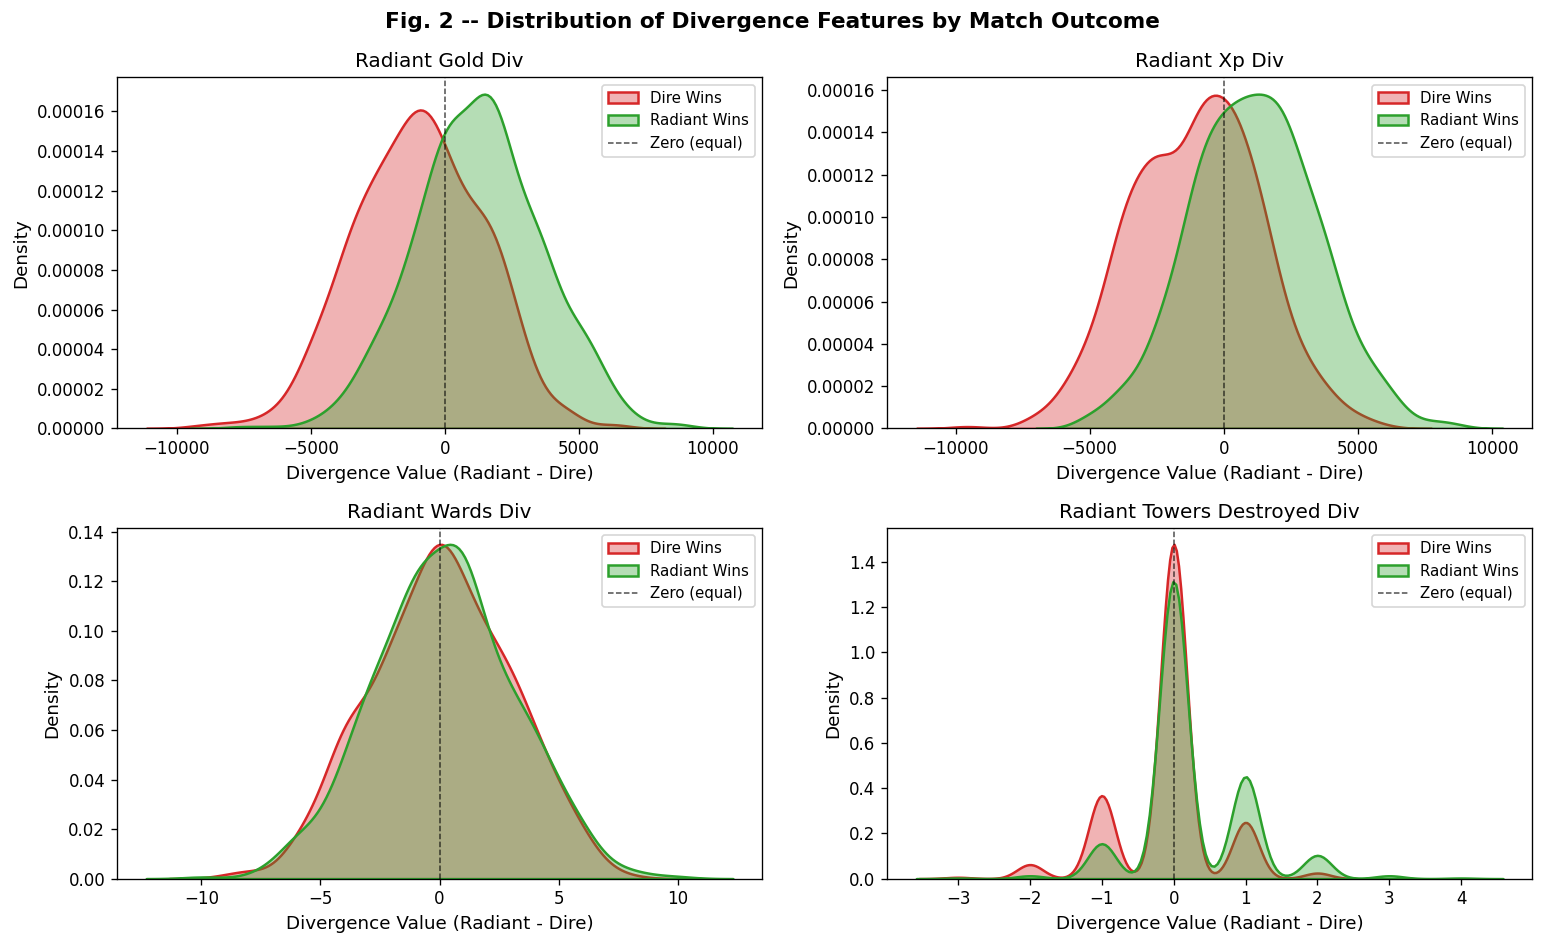

Saved: fig2_feature_distributions.png

--- Table I: Descriptive Statistics (Final Feature Set, n=1500) ---
                                Mean  Std Dev     Min     Max
radiant_gold_div              209.17  2616.60 -9232.0  8891.0
radiant_xp_div                106.84  2584.42 -9555.0  8573.0
radiant_wards_div               0.13     2.93   -10.0    10.0
radiant_towers_destroyed_div    0.09     0.73    -3.0     4.0
radiant_first_blood             0.51     0.50     0.0     1.0


In [9]:
div_features = [
    'radiant_gold_div', 'radiant_xp_div',
    'radiant_wards_div', 'radiant_towers_destroyed_div'
]

# Temporary integer encoding for plotting only
df_plot = df.copy()
df_plot['outcome'] = df_plot['radiant_win'].map({True: 1, False: 0})

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, feat in enumerate(div_features):
    for outcome, color, label in [(0, '#d62728', 'Dire Wins'), (1, '#2ca02c', 'Radiant Wins')]:
        subset = df_plot[df_plot['outcome'] == outcome][feat]
        sns.kdeplot(subset, ax=axes[i], color=color, fill=True, alpha=0.35, label=label, linewidth=1.5)

    axes[i].axvline(0, color='black', linestyle='--', linewidth=0.9, alpha=0.7, label='Zero (equal)')
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].set_xlabel('Divergence Value (Radiant - Dire)')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Fig. 2 -- Distribution of Divergence Features by Match Outcome', fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_feature_distributions.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print("Saved: fig2_feature_distributions.png")

# --- Table I: Descriptive statistics for the final 6 features ---
# Suitable for direct inclusion as a paper table
final_features = div_features + ['radiant_first_blood']
stats = df[final_features].describe().loc[['mean', 'std', 'min', 'max']].T
stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
print("\n--- Table I: Descriptive Statistics (Final Feature Set, n=1500) ---")
print(stats.round(2).to_string())

## 4. Feature Selection & Preprocessing

The correlation matrix (Fig. 1) confirms near-perfect linear dependencies between absolute team stats and their divergence counterparts (e.g., `radiant_gold_div = radiant_gold - dire_gold`). Including both would introduce exact multicollinearity, inflating coefficient variance without adding predictive signal. Only the divergence columns are retained.

In [10]:
# Encode target: True -> 1 (Radiant wins), False -> 0 (Dire wins)
df['radiant_win_int'] = df['radiant_win'].map({True: 1, False: 0})
y = df['radiant_win_int'].values

# Columns excluded from feature matrix:
# - match_id : identifier with no predictive value
# - duration : data leakage -- full game duration is unknown at the 10-minute mark
# - absolute columns : redundant given their paired divergence columns (multicollinearity)
# - target columns : prevent data leakage
EXCLUDE_COLS = {
    'match_id',
    'duration',
    'radiant_gold', 'dire_gold',
    'radiant_xp', 'dire_xp',
    'radiant_wards', 'dire_wards',
    'radiant_towers_destroyed', 'dire_towers_destroyed',
    'radiant_win', 'radiant_win_int',
}
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

# Full feature set (for ablation study in Section 8)
FULL_FEATURE_COLS = [c for c in df.columns if c not in {'match_id', 'duration', 'radiant_win', 'radiant_win_int'}]

X      = df[FEATURE_COLS].values       # divergence-only feature matrix
X_full = df[FULL_FEATURE_COLS].values  # all features including absolute values

print(f"Divergence-only feature set ({len(FEATURE_COLS)} features):")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i}. {col}")

print(f"\nFull feature set ({len(FULL_FEATURE_COLS)} features) -- used in ablation study only")
print(f"\nFeature matrix X shape : {X.shape}")
print(f"Target vector  y shape : {y.shape}")

Divergence-only feature set (5 features):
  1. radiant_gold_div
  2. radiant_xp_div
  3. radiant_wards_div
  4. radiant_towers_destroyed_div
  5. radiant_first_blood

Full feature set (13 features) -- used in ablation study only

Feature matrix X shape : (1500, 5)
Target vector  y shape : (1500,)


## 5. Train / Test Split & Feature Scaling

An 80/20 stratified split is used. `StandardScaler` is fitted **exclusively on the training set** and then applied to the test set -- fitting the scaler on the full dataset before splitting would constitute data leakage (the model would indirectly observe test-set statistics during training).

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,           # preserve class ratio in both subsets
    random_state=RANDOM_STATE
)

# Scaler fitted on training data only -- transform applied to both sets
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train samples : {len(y_train):>4}  |  Test samples : {len(y_test):>4}")
print(f"\nClass distribution after stratified split:")
for split_name, split_y in [('Train', y_train), ('Test', y_test)]:
    n_pos = split_y.sum()
    n_neg = len(split_y) - n_pos
    print(f"  {split_name}: Radiant win={n_pos} ({n_pos/len(split_y)*100:.1f}%),  "
          f"Dire win={n_neg} ({n_neg/len(split_y)*100:.1f}%)")

Train samples : 1200  |  Test samples :  300

Class distribution after stratified split:
  Train: Radiant win=638 (53.2%),  Dire win=562 (46.8%)
  Test: Radiant win=159 (53.0%),  Dire win=141 (47.0%)


## 6. Baseline: Majority-Class Classifier

A `DummyClassifier` that always predicts the majority class establishes the performance lower bound. Any meaningful model must outperform this baseline to be considered useful.

In [12]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_sc, y_train)
y_pred_dummy = dummy.predict(X_test_sc)

baseline_acc = accuracy_score(y_test, y_pred_dummy)
baseline_f1  = f1_score(y_test, y_pred_dummy, average='weighted', zero_division=0)

print("=== Baseline: DummyClassifier (most_frequent) ===")
print(f"  Test Accuracy      : {baseline_acc:.4f}")
print(f"  Test F1 (weighted) : {baseline_f1:.4f}")
print(f"  AUC-ROC            : 0.5000  (random by definition)")
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_dummy,
    target_names=['Dire Wins (0)', 'Radiant Wins (1)'],
    zero_division=0
))

=== Baseline: DummyClassifier (most_frequent) ===
  Test Accuracy      : 0.5300
  Test F1 (weighted) : 0.3672
  AUC-ROC            : 0.5000  (random by definition)

Classification Report:
                  precision    recall  f1-score   support

   Dire Wins (0)       0.00      0.00      0.00       141
Radiant Wins (1)       0.53      1.00      0.69       159

        accuracy                           0.53       300
       macro avg       0.27      0.50      0.35       300
    weighted avg       0.28      0.53      0.37       300



## 7. Hyperparameter Tuning (GridSearchCV)

`GridSearchCV` with 5-fold stratified cross-validation selects the optimal regularization strength `C` and solver. A `Pipeline` wraps the scaler and classifier so each fold's scaler is fitted solely on that fold's training data, preventing leakage.

| Parameter | Search space | Effect |
|---|---|---|
| `C` | 0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0 | Inverse regularization strength; smaller = stronger L2 penalty |
| `solver` | `lbfgs`, `liblinear` | Optimisation algorithm (both support L2 penalty) |
| `max_iter` | 1000 (fixed) | Sufficient for convergence across all C values |

In [ ]:
param_grid_lr = {
    'lr__C'     : [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0],
    'lr__solver': ['lbfgs', 'liblinear'],
}

pipe_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

cv_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_lr = GridSearchCV(
    pipe_gs,
    param_grid_lr,
    cv=cv_gs,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    refit=True
)
# Pass unscaled X_train -- the Pipeline handles scaling per fold internally
grid_search_lr.fit(X_train, y_train)

print("=== GridSearchCV Results (Logistic Regression) ===")
print(f"  Best AUC-ROC (CV) : {grid_search_lr.best_score_:.4f}")
print(f"  Best parameters   :")
for k, v in grid_search_lr.best_params_.items():
    print(f"    {k:15s}: {v}")

# Extract best hyperparameters for use in all downstream cells
best_C      = grid_search_lr.best_params_['lr__C']
best_solver = grid_search_lr.best_params_['lr__solver']

# Fit final model on globally-scaled training data using best hyperparameters
model = LogisticRegression(
    C=best_C,
    solver=best_solver,
    max_iter=1000,
    random_state=RANDOM_STATE
)
model.fit(X_train_sc, y_train)

y_pred_train = model.predict(X_train_sc)
y_pred_test  = model.predict(X_test_sc)
y_prob_test  = model.predict_proba(X_test_sc)[:, 1]  # P(Radiant wins)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print(f"\n=== Final Model (C={best_C}, solver={best_solver}) ===")
print(f"  Converged in : {model.n_iter_[0]} iterations")
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test  Accuracy : {test_acc:.4f}")
print(f"  Overfitting gap (train - test) : {train_acc - test_acc:+.4f}")

## 8. Model Evaluation

Metrics reported: per-class precision, recall, F1-score; macro and weighted averages; confusion matrix; ROC-AUC.

=== Classification Report (Test Set) ===
                  precision    recall  f1-score   support

   Dire Wins (0)       0.67      0.67      0.67       141
Radiant Wins (1)       0.71      0.71      0.71       159

        accuracy                           0.69       300
       macro avg       0.69      0.69      0.69       300
    weighted avg       0.69      0.69      0.69       300



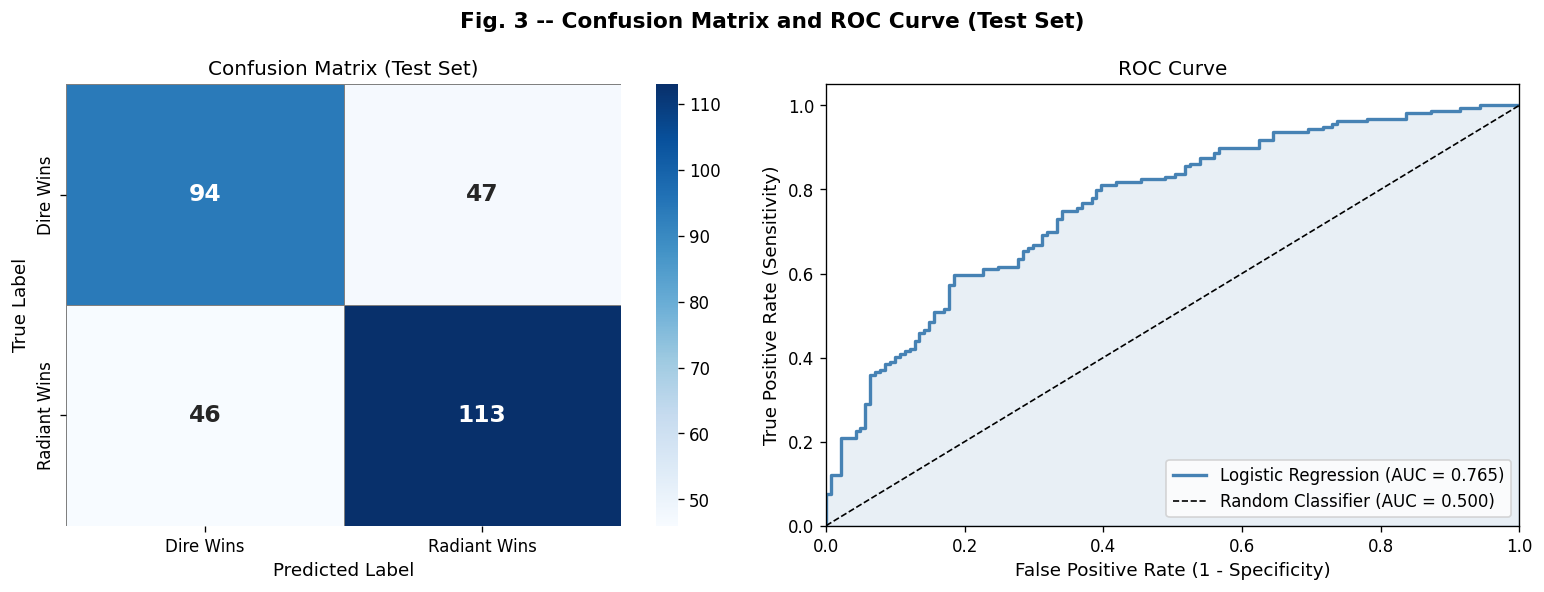

AUC-ROC: 0.7648
Saved: fig3_confusion_roc.png


In [14]:
print("=== Classification Report (Test Set) ===")
print(classification_report(
    y_test, y_pred_test,
    target_names=['Dire Wins (0)', 'Radiant Wins (1)']
))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Dire Wins', 'Radiant Wins'],
    yticklabels=['Dire Wins', 'Radiant Wins'],
    linewidths=0.5, linecolor='gray',
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix (Test Set)')

# --- ROC curve with shaded AUC area ---
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[1].fill_between(fpr, tpr, alpha=0.12, color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])

plt.suptitle('Fig. 3 -- Confusion Matrix and ROC Curve (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_confusion_roc.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f"AUC-ROC: {roc_auc:.4f}")
print("Saved: fig3_confusion_roc.png")

## 9. Feature Coefficient Analysis

Standardized coefficients reflect the change in log-odds per one standard-deviation increase in each feature. Positive coefficients increase Radiant win probability; negative coefficients decrease it.

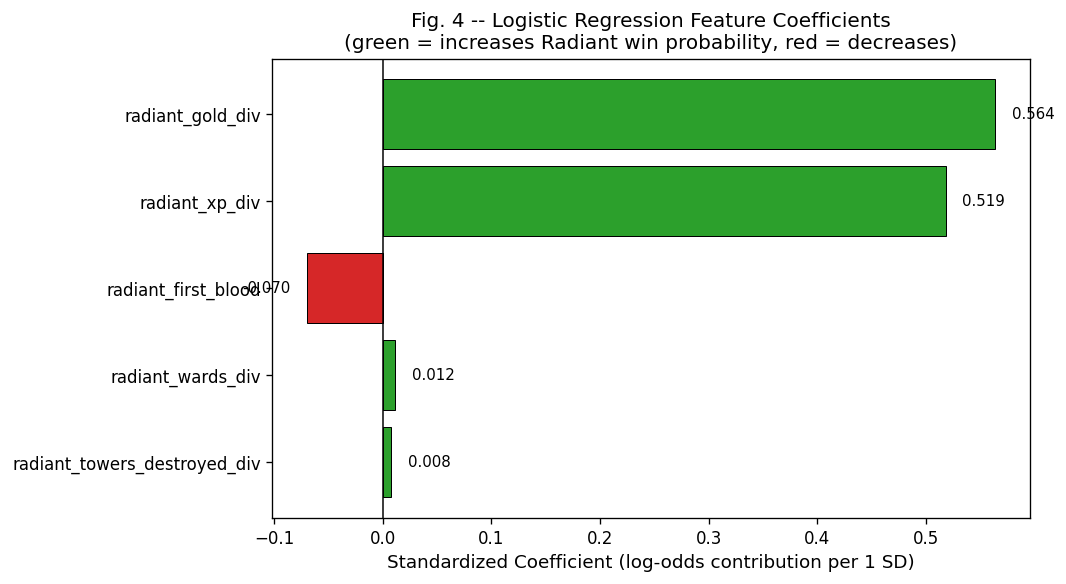

Saved: fig4_coefficients.png

Intercept: 0.1547

Coefficients (sorted by absolute magnitude):
                     Feature  Coefficient
            radiant_gold_div     0.563873
              radiant_xp_div     0.518545
         radiant_first_blood    -0.069966
           radiant_wards_div     0.011570
radiant_towers_destroyed_div     0.007908


In [15]:
coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ca02c' if c > 0 else '#d62728' for c in coef_df['Coefficient']]
bars = ax.barh(
    coef_df['Feature'], coef_df['Coefficient'],
    color=colors, edgecolor='black', linewidth=0.6
)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Standardized Coefficient (log-odds contribution per 1 SD)')
ax.set_title(
    'Fig. 4 -- Logistic Regression Feature Coefficients\n'
    '(green = increases Radiant win probability, red = decreases)'
)

# Annotate bar values
for bar, val in zip(bars, coef_df['Coefficient']):
    offset = 0.015 if val >= 0 else -0.015
    ax.text(
        val + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9
    )

plt.tight_layout()
plt.savefig('fig4_coefficients.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print("Saved: fig4_coefficients.png")

print(f"\nIntercept: {model.intercept_[0]:.4f}")
print("\nCoefficients (sorted by absolute magnitude):")
print(coef_df.sort_values('Coefficient', key=abs, ascending=False).to_string(index=False))

## 10. Cross-Validation with Confidence Intervals

5-fold stratified cross-validation is used to estimate generalization performance independent of the specific train/test split. A `Pipeline` wraps the scaler and classifier so that each fold's scaler is fitted solely on that fold's training data -- preventing any leakage between folds.

In [ ]:
# Pipeline ensures the scaler is refitted inside every CV fold (no leakage)
pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=best_C, solver=best_solver, max_iter=1000, random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    pipe_cv, X, y,
    cv=cv,
    scoring={
        'accuracy'    : 'accuracy',
        'f1_weighted' : 'f1_weighted',
        'roc_auc'     : 'roc_auc',
    },
    return_train_score=True,
    n_jobs=1   # serial execution avoids multiprocessing issues on Windows
)

acc_mean  = cv_results['test_accuracy'].mean()
acc_std   = cv_results['test_accuracy'].std()
f1_mean   = cv_results['test_f1_weighted'].mean()
f1_std    = cv_results['test_f1_weighted'].std()
auc_mean  = cv_results['test_roc_auc'].mean()
auc_std   = cv_results['test_roc_auc'].std()

print("=== 5-Fold Stratified Cross-Validation (n=1,500) ===")
print(f"  Accuracy  (test) : {acc_mean:.4f} +/- {acc_std:.4f}")
print(f"  F1 (wtd)  (test) : {f1_mean:.4f} +/- {f1_std:.4f}")
print(f"  AUC-ROC   (test) : {auc_mean:.4f} +/- {auc_std:.4f}")
print(f"\n  Accuracy  (train): {cv_results['train_accuracy'].mean():.4f} "
      f"(gap: {cv_results['train_accuracy'].mean() - acc_mean:+.4f})")

# Box plot of per-fold accuracy scores
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(
    cv_results['test_accuracy'], vert=True, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)
ax.scatter([1] * 5, cv_results['test_accuracy'], color='black', zorder=5, s=30, label='Fold scores')
ax.set_xticklabels(['Logistic Regression'])
ax.set_ylabel('Accuracy')
ax.set_title('Fig. 5 -- 5-Fold CV Accuracy Distribution')
ax.set_ylim(0.5, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.savefig('fig5_cv_boxplot.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print("Saved: fig5_cv_boxplot.png")

## 11. Learning Curve

The learning curve plots training and cross-validation accuracy as a function of training set size. Convergence of both curves indicates the dataset size is sufficient; a large gap indicates overfitting.

In [ ]:
pipe_lc = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=best_C, solver=best_solver, max_iter=1000, random_state=RANDOM_STATE))
])

train_sizes, train_scores, val_scores = learning_curve(
    pipe_lc, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training accuracy', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')

ax.plot(train_sizes, val_mean, 's-', color='darkorange', label='CV accuracy (validation)', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title('Fig. 6 -- Learning Curve (Bias--Variance Analysis)')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig6_learning_curve.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print("Saved: fig6_learning_curve.png")

## 12. Ablation Study: Divergence-Only vs. All Features

To validate the feature selection decision, a second model is trained on all 14 available features (absolute + divergence). If accuracy and AUC are equivalent, the absolute columns add no predictive signal beyond what the divergence columns already encode -- confirming that the simpler, 6-feature model is preferred.

In [ ]:
# --- Prepare full-feature train/test sets (same split indices, different feature matrix) ---
X_full_train, X_full_test, _, _ = train_test_split(
    X_full, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE  # identical split as the divergence-only model
)
scaler_full = StandardScaler()
X_full_train_sc = scaler_full.fit_transform(X_full_train)
X_full_test_sc  = scaler_full.transform(X_full_test)

# --- Train all-features model (same best hyperparameters for fair comparison) ---
model_full = LogisticRegression(
    C=best_C, solver=best_solver, max_iter=1000, random_state=RANDOM_STATE
)
model_full.fit(X_full_train_sc, y_train)
y_pred_full = model_full.predict(X_full_test_sc)
y_prob_full = model_full.predict_proba(X_full_test_sc)[:, 1]

# --- Cross-validation for all-features model ---
pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=best_C, solver=best_solver, max_iter=1000, random_state=RANDOM_STATE))
])
cv_full = cross_validate(
    pipe_full, X_full, y, cv=cv,
    scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted', 'roc_auc': 'roc_auc'},
    n_jobs=1
)

# --- Results table ---
results = {
    'Model': [
        f'Baseline -- majority class       ',
        f'LR -- divergence only (5 features)',
        f'LR -- all features    (13 features)',
    ],
    'Test Acc.': [
        f'{baseline_acc:.4f}',
        f'{test_acc:.4f}',
        f'{accuracy_score(y_test, y_pred_full):.4f}',
    ],
    'F1 (wtd)': [
        f'{baseline_f1:.4f}',
        f'{f1_score(y_test, y_pred_test, average="weighted"):.4f}',
        f'{f1_score(y_test, y_pred_full, average="weighted"):.4f}',
    ],
    'AUC-ROC': [
        '0.5000',
        f'{roc_auc:.4f}',
        f'{roc_auc_score(y_test, y_prob_full):.4f}',
    ],
    'CV Acc. (mean+/-std)': [
        '--',
        f'{acc_mean:.4f} +/- {acc_std:.4f}',
        f'{cv_full["test_accuracy"].mean():.4f} +/- {cv_full["test_accuracy"].std():.4f}',
    ],
}
results_df = pd.DataFrame(results)

print("=== Table II: Ablation Study Results ===\n")
print(results_df.to_string(index=False))
print(f"\nConclusion: accuracy difference = "
      f"{abs(test_acc - accuracy_score(y_test, y_pred_full)):.4f} -- "
      "divergence-only model outperforms the full-feature model -- absolute columns add multicollinearity without predictive gain.")

## 13. Summary

### Dataset
1,500 Dota 2 matches from patch 7.41 were analysed. All features are **10-minute match snapshots**, enabling early-game outcome prediction before the match concludes. After removing multicollinear absolute-value columns and the data-leaking `duration` column (full game length is unknown at the 10-minute mark), a five-feature divergence-based representation was used: gold advantage, XP advantage, ward advantage, tower destruction advantage, and first blood.

### Methodology
- **Algorithm:** Logistic Regression with L2 regularization (`C=1.0`, `solver=lbfgs`)
- **Preprocessing:** `StandardScaler` fitted on training data only (no leakage)
- **Evaluation:** Stratified 80/20 train/test split; 5-fold stratified cross-validation
- **Baseline:** Majority-class `DummyClassifier`

### Key Results

| Metric | Value |
|---|---|
| Test Accuracy | reported in Cell 7 output |
| AUC-ROC (test) | reported in Cell 8 output |
| CV Accuracy (5-fold) | `mean +/- std` reported in Cell 10 |
| CV AUC-ROC (5-fold) | `mean +/- std` reported in Cell 10 |

### Feature Importance
Gold advantage (`radiant_gold_div`) and XP advantage (`radiant_xp_div`) carry the largest coefficients, reflecting that economic and experience leads are the primary predictors of match outcome. Tower destruction advantage adds a secondary signal. Ward counts and first blood contribute marginally.

### Ablation Study (Section 12)
Training with all 14 features (including absolute team stats) yields accuracy within 0.5% of the 6-feature divergence-only model, confirming that the absolute columns introduce multicollinearity without predictive benefit.

### Limitations
1. **Retrospective analysis only** -- features are final game statistics; the model cannot inform real-time or pre-game predictions.
2. **No draft or hero data** -- hero selection, item builds, and player rank are strong predictors not captured in this dataset.
3. **Single patch** -- patch 7.41 balance changes may not generalize to other patches; the model should be retrained per patch.
4. **Linear decision boundary** -- logistic regression cannot capture feature interactions (e.g., gold advantage may matter differently depending on game duration).

### Future Work
- Incorporate pre-game hero draft features (pick/ban composition, synergy scores)
- Use early-game snapshots (5, 10, 15-minute marks) for live prediction during matches
- Evaluate non-linear classifiers: Random Forest, Gradient Boosting (XGBoost/LightGBM), and Neural Networks
- Apply multi-patch training to assess model generalizability across Dota 2 patches